# Lending Club Loans EDA

Goal: draw insights from the raw `accepted_2007_to_2018Q4.csv` dump and motivate every preprocessing decision in `src.data.lending_club`. Each section answers one concrete question:

0. **Sampling note** — the CSV is sorted by `issue_d` and the first 200 K rows are *all* 2015 issues, so `load_lending_club_raw` randomly samples `nrows` rows (default 5 K) from the full ~1.35 M resolved-loan pool, seeded by `random_state` so experiments are reproducible. 5 K leaves ~1 K loans per fold under 5-fold CV (~200 defaults / fold); optional cache via `preprocess.py` avoids re-reading the raw CSV.
1. **Target balance** — derive `y` from `loan_status`, drop unresolved loans (`Current`, `In Grace Period`, `Late ...`).
2. **Missingness profile** — confirm the 30 % cutoff sits in a natural gap.
3. **Leakage columns** — fields recorded *after* loan origination (`recoveries`, `last_fico_*`, `total_pymnt_*`, `hardship_*`, `settlement_*`, ...) trivially reveal the outcome and must be dropped.
4. **Free-text / ID / date / high-cardinality columns** — e.g. `id`, `url`, `desc`, `emp_title`, `zip_code`, `addr_state`, `issue_d`, `earliest_cr_line`.
5. **String-encoded numerics** — `term` (`' 36 months'`), `emp_length` (`'< 1 year'` ... `'10+ years'`).
6. **Ordinal categoricals** — `grade` (A–G), `sub_grade` (A1–G5) map cleanly to integers and are monotone in default rate.
7. **Nominal categoricals** — `home_ownership`, `verification_status`, `purpose`, `application_type`, `initial_list_status` need one-hot in stage 3.
8. **Skewed dollar / count columns** — `annual_inc`, `revol_bal`, `tot_coll_amt`, ... motivate a `log1p` transform.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import load_lending_club, load_lending_club_raw

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(context="notebook", style="whitegrid")

In [2]:
X_raw, y = load_lending_club_raw(nrows=5_000)  # randomly sampled across 2007-2018, seeded
X = X_raw.copy()

print(f"raw         : X={X_raw.shape}, y={y.shape}")
print(f"raw numeric : X={X_raw.select_dtypes(include=[np.number]).shape}")

raw         : X=(5000, 150), y=(5000,)
raw numeric : X=(5000, 114)


## 1. Target balance

`load_lending_club_raw` already filtered `loan_status` to the resolved set (`Charged Off` / `Default` / `Fully Paid`, plus the two `Does not meet the credit policy.` variants), then mapped Charged Off / Default → 1 and Fully Paid → 0. We expect a ~20 % default rate — imbalanced enough that **AUC** is the headline metric, not raw accuracy.

In [3]:
counts = y.value_counts().sort_index().rename({0: "fully paid (y=0)", 1: "default (y=1)"})
print(counts.to_string())
print(f"\ndefault rate: {y.mean():.3%}  (n = {len(y):,})")

loan_status
fully paid (y=0)    3940
default (y=1)       1060

default rate: 21.200%  (n = 5,000)


## 2. Missingness profile

The raw file mixes columns that are essentially complete with a long tail of post-2017 / joint-application / hardship features that are 99–100 % missing for the bulk of the data. We want to confirm the 30 % cutoff sits in a natural gap and isn't throwing away useful signal.

numeric cols: 114
0.100    69
0.200    70
0.300    70
0.400    70
0.500    70
0.700    86
0.900    89


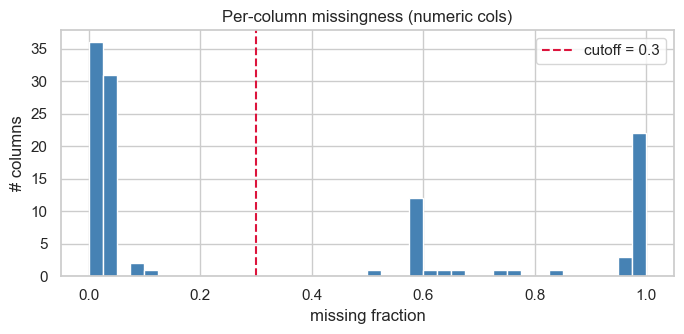

In [4]:
X_num = X.select_dtypes(include=[np.number])
miss = X_num.isna().mean().sort_values(ascending=False)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
kept = pd.Series({t: int((miss <= t).sum()) for t in thresholds}, name="cols kept")
print(f"numeric cols: {len(miss)}")
print(kept.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(miss.values, bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.3, color="crimson", linestyle="--", label="cutoff = 0.3")
ax.set_xlabel("missing fraction")
ax.set_ylabel("# columns")
ax.set_title("Per-column missingness (numeric cols)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
print("Top 15 numeric cols by missingness (these are dropped at 30%):")
print(miss.head(15).round(3).to_string())

Top 15 numeric cols by missingness (these are dropped at 30%):
member_id                                    1.000
orig_projected_additional_accrued_interest   0.997
hardship_last_payment_amount                 0.995
hardship_payoff_balance_amount               0.995
hardship_dpd                                 0.995
hardship_length                              0.995
hardship_amount                              0.995
deferral_term                                0.995
sec_app_mths_since_last_major_derog          0.994
sec_app_revol_util                           0.984
sec_app_chargeoff_within_12_mths             0.984
sec_app_mort_acc                             0.984
sec_app_open_acc                             0.984
sec_app_open_act_il                          0.984
sec_app_num_rev_accts                        0.984


## 3. Leakage columns

Several numeric fields are recorded *after* the loan has played out, so they trivially reveal the outcome (e.g. `recoveries > 0` essentially means default). Dropping them is critical for an honest benchmark. The table below ranks numeric cols by `|corr|` with the default label — the top entries jump out as obviously leaky.

In [6]:
corr = X_num.corrwith(y).abs().sort_values(ascending=False)
print("Top 15 numeric cols by |corr| with default label:")
print(corr.head(15).round(3).to_string())

Top 15 numeric cols by |corr| with default label:
last_fico_range_high                         0.683
last_fico_range_low                          0.580
hardship_payoff_balance_amount               0.546
recoveries                                   0.495
hardship_amount                              0.475
collection_recovery_fee                      0.470
total_rec_prncp                              0.453
sec_app_fico_range_low                       0.444
sec_app_fico_range_high                      0.444
orig_projected_additional_accrued_interest   0.414
hardship_last_payment_amount                 0.400
sec_app_inq_last_6mths                       0.397
last_pymnt_amnt                              0.364
total_pymnt                                  0.325
total_pymnt_inv                              0.325


/Users/dongyoun/miniconda3/envs/mi-feature/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/dongyoun/miniconda3/envs/mi-feature/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Everything above ~0.2 is a post-origination field. The full leakage list dropped in `clean_lending_club` covers:

- **Payment history**: `out_prncp(_inv)`, `total_pymnt(_inv)`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`, `recoveries`, `collection_recovery_fee`, `last_pymnt_d`, `last_pymnt_amnt`, `next_pymnt_d`.
- **Post-loan FICO pull**: `last_fico_range_high/low`, `last_credit_pull_d`.
- **Resolution flags**: `debt_settlement_*`, `settlement_*`, `hardship_*`, `deferral_term`, `orig_projected_additional_accrued_interest`.

## 4. Free-text / ID / date / high-cardinality columns

Object-typed columns split into three buckets:

- **Free-text / IDs**: `id`, `member_id`, `url`, `desc`, `emp_title`, `title` — huge cardinality, no useful signal without NLP. Drop.
- **Geography / date strings**: `zip_code` (888 levels), `addr_state` (49 levels), `issue_d`, `earliest_cr_line` — dropping for a minimal numeric baseline; could be re-added later (e.g. `earliest_cr_line` → credit-history-length).
- **Single-valued**: `pymnt_plan`, `disbursement_method`, `hardship_flag` are constant on the resolved subset — zero variance, drop.
- **Categorical (kept)**: discussed in sections 5–7 below.

In [7]:
obj = X.select_dtypes(include="object")
summary = pd.DataFrame({
    "n_unique": obj.nunique(dropna=True),
    "miss_pct": obj.isna().mean().round(3),
    "sample": [obj[c].dropna().head(1).tolist() for c in obj.columns],
}).sort_values("n_unique", ascending=False)
print(f"object cols: {obj.shape[1]}")
print(summary.to_string())

object cols: 36
                           n_unique  miss_pct                                                                                                                                                                                                                                                                                                                                                                 sample
url                            5000     0.000                                                                                                                                                                                                                                                                                                    [https://lendingclub.com/browse/loanDetail.action?loan_id=68376378]
emp_title                      3358     0.061                                                                                                                                 

/var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_1372/284585743.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj = X.select_dtypes(include="object")


## 5. String-encoded numerics: `term` and `emp_length`

Two columns are stored as strings but are really integers in disguise. `clean_lending_club` parses them in stage 2 so they pass through median imputation and scaling untouched.

- `term`: `' 36 months'` / `' 60 months'` → `36` / `60`.
- `emp_length`: `'< 1 year'`, `'1 year'`, ..., `'10+ years'` → `0`, `1`, ..., `10` (treated as ordinal).

In [8]:
print("term value_counts:")
print(X["term"].value_counts(dropna=False).to_string())
print("\nemp_length value_counts:")
print(X["emp_length"].value_counts(dropna=False).to_string())

by_term = pd.concat([X["term"].str.strip(), y.rename("default")], axis=1).groupby("term")["default"].mean()
print(f"\ndefault rate by term:\n{by_term.to_string()}")

term value_counts:
term
36 months    3772
60 months    1228

emp_length value_counts:
emp_length
10+ years    1657
2 years       428
3 years       408
< 1 year      377
1 year        343
4 years       342
5 years       316
NaN           279
6 years       235
8 years       216
7 years       215
9 years       184

default rate by term:
term
36 months   0.171
60 months   0.338


## 6. Ordinal categoricals: `grade` and `sub_grade`

LendingClub assigns each loan a letter grade A–G (and sub-grade A1–G5) that is the issuer's own internal risk score. It is strictly ordinal in default rate, so we map to integers (`A`→1 ... `G`→7; `A1`→1 ... `G5`→35) and let the downstream scaler handle the magnitude.

default rate by grade:
       mean  size
grade            
A     0.065   831
B     0.133  1420
C     0.235  1424
D     0.342   786
E     0.376   378
F     0.419   124
G     0.541    37


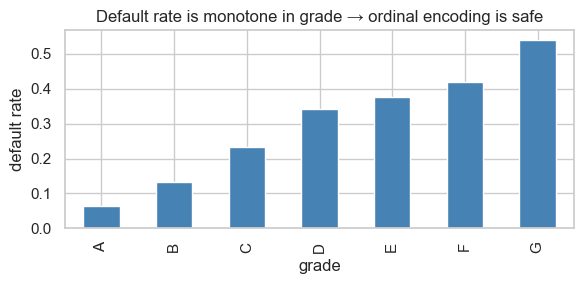

In [9]:
grade_default = pd.concat([X["grade"], y.rename("default")], axis=1).groupby("grade")["default"].agg(["mean", "size"]).sort_index()
print("default rate by grade:")
print(grade_default.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
grade_default["mean"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("default rate")
ax.set_title("Default rate is monotone in grade → ordinal encoding is safe")
plt.tight_layout()
plt.show()

## 7. Nominal categoricals

These are low-cardinality string categoricals with no inherent ordering. Stage 2 integer-encodes them (so they survive median imputation as numerics, mirroring NHANES); stage 3 then `pd.get_dummies` them with `drop_first=True`.

In [10]:
NOMINAL = ["home_ownership", "verification_status", "purpose", "application_type", "initial_list_status"]
rows = []
for c in NOMINAL:
    s = X[c]
    rows.append({
        "col": c,
        "n_unique": s.nunique(),
        "miss_pct": s.isna().mean(),
        "top": s.value_counts(dropna=False).idxmax(),
        "top_pct": s.value_counts(dropna=False, normalize=True).iloc[0],
    })
print(pd.DataFrame(rows).to_string(index=False))

                col  n_unique  miss_pct                top  top_pct
     home_ownership         5     0.000           MORTGAGE    0.500
verification_status         3     0.000    Source Verified    0.374
            purpose        14     0.000 debt_consolidation    0.592
   application_type         2     0.000         Individual    0.979
initial_list_status         2     0.000                  w    0.595


## 8. Skewed dollar / count columns → `log1p`

Borrower wealth (`annual_inc`) and counters (`tot_coll_amt`, `delinq_amnt`, ...) have heavy right tails: a handful of millionaires / many-delinquency outliers dominate the standard deviation and can wreck linear / distance-based models. We `log1p` any non-negative column whose training-fold `skew` exceeds **2.0** (chosen below from the bimodal-looking gap).

Top 15 right-skewed numeric cols (post stage 2):
delinq_amnt                  64.870
tot_coll_amt                 32.450
num_tl_120dpd_2m             25.490
num_tl_30dpd                 21.520
tax_liens                    19.350
chargeoff_within_12_mths     19.160
acc_now_delinq               15.960
revol_bal                    15.380
num_tl_90g_dpd_24m           14.170
dti                           9.700
collections_12_mths_ex_med    7.980
pub_rec                       7.010
delinq_2yrs                   6.710
application_type              6.620
annual_inc                    6.420


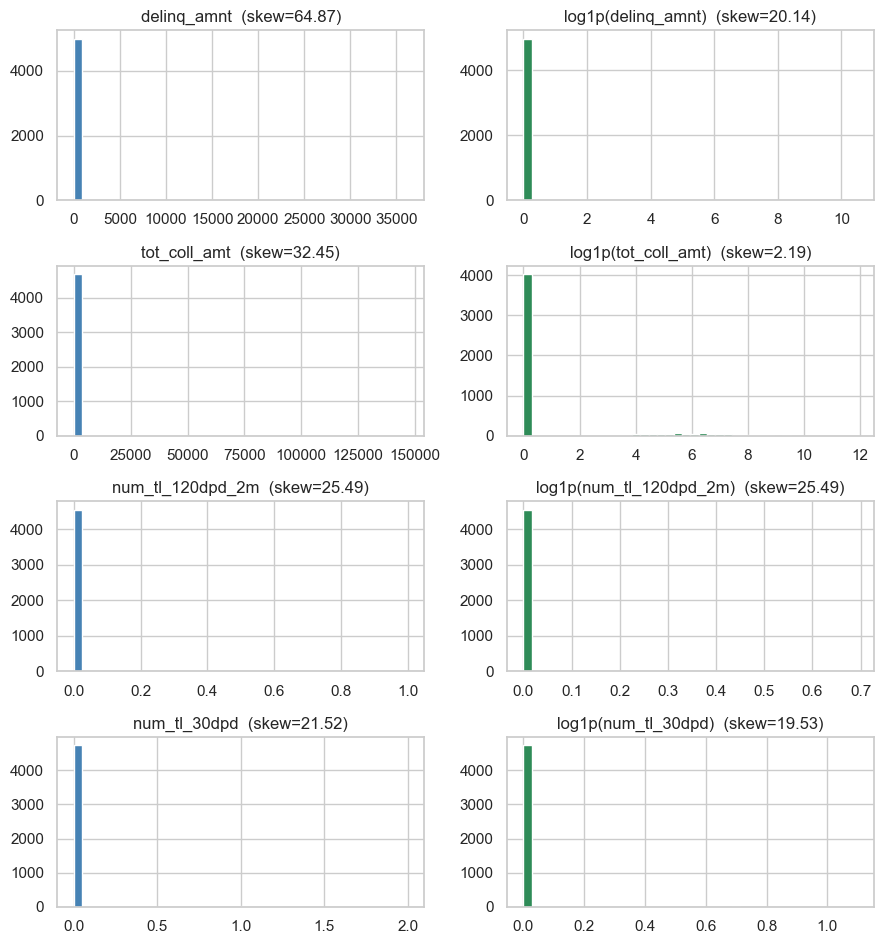

In [11]:
X_clean, _ = load_lending_club(nrows=5_000)
nonneg = [c for c in X_clean.columns if (X_clean[c].dropna() >= 0).all()]
skew = X_clean[nonneg].skew().sort_values(ascending=False)
print("Top 15 right-skewed numeric cols (post stage 2):")
print(skew.head(15).round(2).to_string())

top = skew.head(4).index.tolist()
fig, axes = plt.subplots(len(top), 2, figsize=(9, 2.4 * len(top)))
for i, col in enumerate(top):
    s = X_clean[col].dropna()
    axes[i, 0].hist(s, bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{col}  (skew={s.skew():.2f})")
    axes[i, 1].hist(np.log1p(s), bins=40, color="seagreen", edgecolor="white")
    axes[i, 1].set_title(f"log1p({col})  (skew={np.log1p(s).skew():.2f})")
plt.tight_layout()
plt.show()

## 9. Final shape after stages 1 + 2

`load_lending_club()` (stages 1 + 2 combined) returns a fully-numeric DataFrame ready for train/val splitting + median imputation. Stage 3 (`preprocess_lending_club`) is fit per fold on training data only, log1p-transforming the heavy-tailed columns above and one-hot-expanding the nominal columns.

In [12]:
X_clean, y_clean = load_lending_club(nrows=5_000)
print(f"clean: X={X_clean.shape}, y={y_clean.shape}")
print(f"dtypes: {X_clean.dtypes.value_counts().to_dict()}")
print(f"any object dtype? {(X_clean.dtypes == object).any()}")
print(f"cols with NaN (handled by per-fold median imputation): {int(X_clean.isna().any().sum())}")

clean: X=(5000, 65), y=(5000,)
dtypes: {dtype('float64'): 65}
any object dtype? False
cols with NaN (handled by per-fold median imputation): 48
